# Gradient Descent vs Stochastic Gradient Descent Demo

In this notebook, we will explore Gradient Descent (GD) and Stochastic Gradient Descent (SGD).
We will generate synthetic data and demonstrate the paths taken by each algorithm during optimization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + 5 * np.random.randn(100, 1)

We first scale the data:

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Gradient Descent Function

The `gradient_descent` function is defined to perform the optimization. This function initializes `theta` (the parameter vector) and `theta_0` (the intercept) to zero. It iteratively updates these parameters to minimize the cost function, which measures the difference between the predicted and actual values. The cost function used here is the Mean Squared Error (MSE), given by $J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$, where $h_\theta(x) = \theta_0 + \theta^T x$ is the hypothesis. The gradients of the cost function with respect to `theta` and `theta_0` are computed and used to update the parameters in the direction that reduces the cost. In the gradient descent algorithm, the **entire dataset** is used to compute the gradient at each step. The update rule is $\theta = \theta - \alpha \frac{\partial J(\theta)}{\partial \theta}$, where $\alpha$ is the learning rate, represented by the variable `learning_rate` in the code. The iterations stop if the change in `theta_0` between consecutive iterations is smaller than a predefined tolerance, indicating convergence. Please note that storing the history of `theta` and `theta_0` values is added solely for visualization purposes and is not essential to the gradient descent algorithm itself.

In [3]:
def gradient_descent(X, y, learning_rate=0.001, max_iter=500, tol=1e-6):
    n_samples, n_features = X.shape
    theta = np.zeros(n_features)
    theta_0 = 0
    history = []

    for iter in range(max_iter):
        predictions = np.dot(X, theta) + theta_0
        errors = predictions - y.flatten()
        
        gradient_theta = 2 * np.dot(X.T, errors) / n_samples
        gradient_theta_0 = 2 * np.mean(errors)

        theta -= learning_rate * gradient_theta
        theta_0 -= learning_rate * gradient_theta_0
        
        history.append((theta.copy(), theta_0))

        if iter > 0 and np.abs(history[-1][1] - history[-2][1]) < tol:
            break

    return theta, theta_0, history

## Stochastic Gradient Descent Function

The `stochastic_gradient_descent` function performs a similar optimization but updates the parameters using one randomly selected training example at a time. This method introduces more noise into the parameter updates, which can help the algorithm escape local minima. The gradients for a single training example are calculated as $\frac{\partial J(\theta)}{\partial \theta} = 2 x_i (h_\theta(x_i) - y_i)$ and $\frac{\partial J(\theta)}{\partial \theta_0} = 2 (h_\theta(x_i) - y_i)$. The parameters `theta` and `theta_0` are updated accordingly. This process is repeated for each sample in the dataset. The history of parameter updates is recorded periodically, which is added solely for visualization purposes and is not essential to the stochastic gradient descent algorithm itself. The loop breaks if the change in the cost function is smaller than the tolerance.

In [4]:
def stochastic_gradient_descent(X, y, learning_rate=0.001, max_iter=500, tol=1e-6):
    n_samples, n_features = X.shape
    theta = np.zeros(n_features)
    theta_0 = 0
    history = []

    for iter in range(max_iter):
        for i in range(n_samples):
            idx = np.random.randint(n_samples)
            X_i = X[idx:idx+1]
            y_i = y[idx:idx+1]

            prediction = np.dot(X_i, theta) + theta_0
            error = prediction - y_i.flatten()
            
            gradient_theta = 2 * np.dot(X_i.T, error)
            gradient_theta_0 = 2 * np.mean(error)

            theta -= learning_rate * gradient_theta
            theta_0 -= learning_rate * gradient_theta_0

            if (iter * n_samples + i) % 100 == 0:
                history.append((theta.copy(), theta_0))

        if iter > 0 and len(history) > 1 and np.abs(history[-1][1] - history[-2][1]) < tol:
            break

    return theta, theta_0, history

## Fitting Models and Plotting Results

First, we define the plot_results function that visualizes the optimization process by creating contour plots of the loss function. It creates a grid of theta0 and theta1 values and computes the loss for each pair. The contour plot shows the loss surface, with lower values indicating better fits. The trajectory of theta and theta_0 updates is superimposed on the plot, with the start and end points highlighted to show the optimization path.

In [5]:
def plot_results(theta_hist, theta_0_hist, title, subplot_index):
    theta0_vals, theta1_vals = np.meshgrid(np.linspace(-1, 8, 100), np.linspace(-1, 2, 100))
    loss_grid = np.array([
        np.mean((theta0 + theta1 * X_scaled.flatten() - y.flatten()) ** 2)
        for theta0, theta1 in zip(theta0_vals.flatten(), theta1_vals.flatten())
    ]).reshape(theta0_vals.shape)

    plt.subplot(1, 2, subplot_index)
    cp = plt.contourf(theta0_vals, theta1_vals, loss_grid, levels=20, cmap='viridis')
    plt.colorbar(label='Loss')
    plt.xlabel('Intercept (theta0)')
    plt.ylabel('Slope (theta1)')
    plt.title(title)
    plt.scatter(theta_0_hist, theta_hist, color='red', s=10, label='Gradient Update')
    plt.plot(theta_0_hist, theta_hist, 'r-')

    plt.scatter(theta_0_hist[0], theta_hist[0], color='blue', marker='o', s=100, label='Start Point', zorder=5)
    plt.scatter(theta_0_hist[-1], theta_hist[-1], color='green', marker='*', s=200, label='End Point', zorder=5)

    plt.legend()

Lastly, we set the learning rate and maximum iterations, then fit the models using gradient descent and stochastic gradient descent. The histories of theta and theta_0 are extracted and plotted using the plot_results function to compare the optimization paths and performance of both algorithms. The resulting plots show the loss surface with the optimization trajectories overlaid, highlighting how each method converges to the solution.

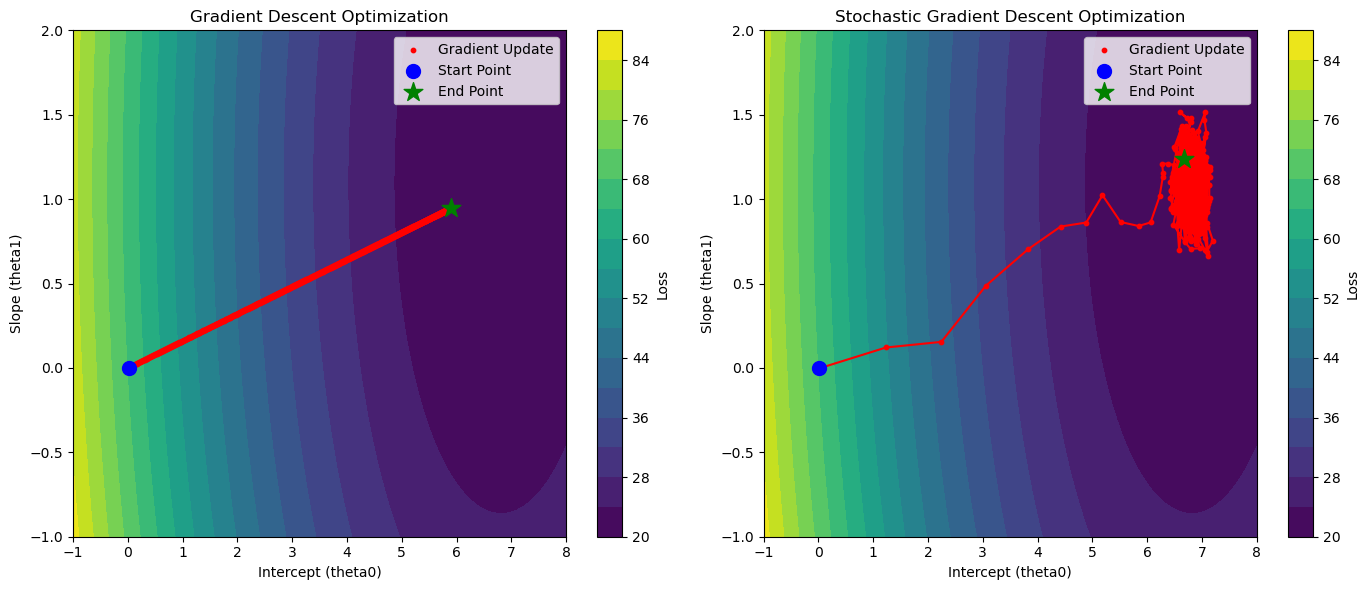

In [6]:
learning_rate = 0.001
max_iteration = 1000

theta_gd, theta_0_gd, history_gd = gradient_descent(X_scaled, y, learning_rate=learning_rate, max_iter=max_iteration)
theta_sgd, theta_0_sgd, history_sgd = stochastic_gradient_descent(X_scaled, y, learning_rate=learning_rate, max_iter=max_iteration)

history_gd_theta, history_gd_theta_0 = zip(*history_gd)
history_sgd_theta, history_sgd_theta_0 = zip(*history_sgd)

plt.figure(figsize=(14, 6))
plot_results(history_gd_theta, history_gd_theta_0, 'Gradient Descent Optimization', 1)
plot_results(history_sgd_theta, history_sgd_theta_0, 'Stochastic Gradient Descent Optimization', 2)
plt.tight_layout()
plt.show()

The plots show the optimization paths of Gradient Descent (GD) and Stochastic Gradient Descent (SGD) on a contour plot of the loss function. The loss function is represented by the color gradient, with lighter colors indicating lower loss values.

### Gradient Descent Optimization
In the left plot, the path of the gradient descent optimization is depicted. In gradient descent, the entire dataset is used to compute the gradient at each step, leading to a smooth and direct path towards the minimum of the loss function.

### Stochastic Gradient Descent Optimization
In the right plot, the path of the stochastic gradient descent optimization is shown. Here, the trajectory appears more erratic compared to the gradient descent plot. This is because SGD updates the parameters using one randomly selected training example at a time, introducing stochasticity (randomness) into the parameter updates. The path is less smooth and shows more fluctuations due to the noisy updates, which can help the algorithm escape local minima but also makes it less stable than standard gradient descent.